Mounted at /content/drive
Device: cuda
Total Images: 2880
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Train: 2448 | Test: 432
Model Ready!
Epoch  1/15 | Loss: 0.7163 | Train: 77.21% | Test: 88.66%
   >>> Best model saved! (88.66%)
Epoch  2/15 | Loss: 0.1629 | Train: 94.57% | Test: 95.60%
   >>> Best model saved! (95.60%)
Epoch  3/15 | Loss: 0.0695 | Train: 97.92% | Test: 95.60%
Epoch  4/15 | Loss: 0.0515 | Train: 98.41% | Test: 97.45%
   >>> Best model saved! (97.45%)
Epoch  5/15 | Loss: 0.0241 | Train: 99.35% | Test: 97.69%
   >>> Best model saved! (97.69%)
Epoch  6/15 | Loss: 0.0189 | Train: 99.47% | Test: 97.45%
Epoch  7/15 | Loss: 0.0256 | Train: 99.02% | Test: 96.53%
Epoch  8/15 | Loss: 0.0133 | Train: 99.59% | Test: 96.30%
Epoch  9/15 | Loss: 0.0043 | Train: 100.00% | Test: 97.92%
   >>> Best model saved! (97.92%)
Epoch 10/15 | Loss: 0.0016 | Train: 100.00% | Test: 97.92%
Epoch 11/15 | Loss: 0.0036 | Train: 99.92% | Test: 97.22%
Epoch 12/15 | Loss: 0.0047 | Train:

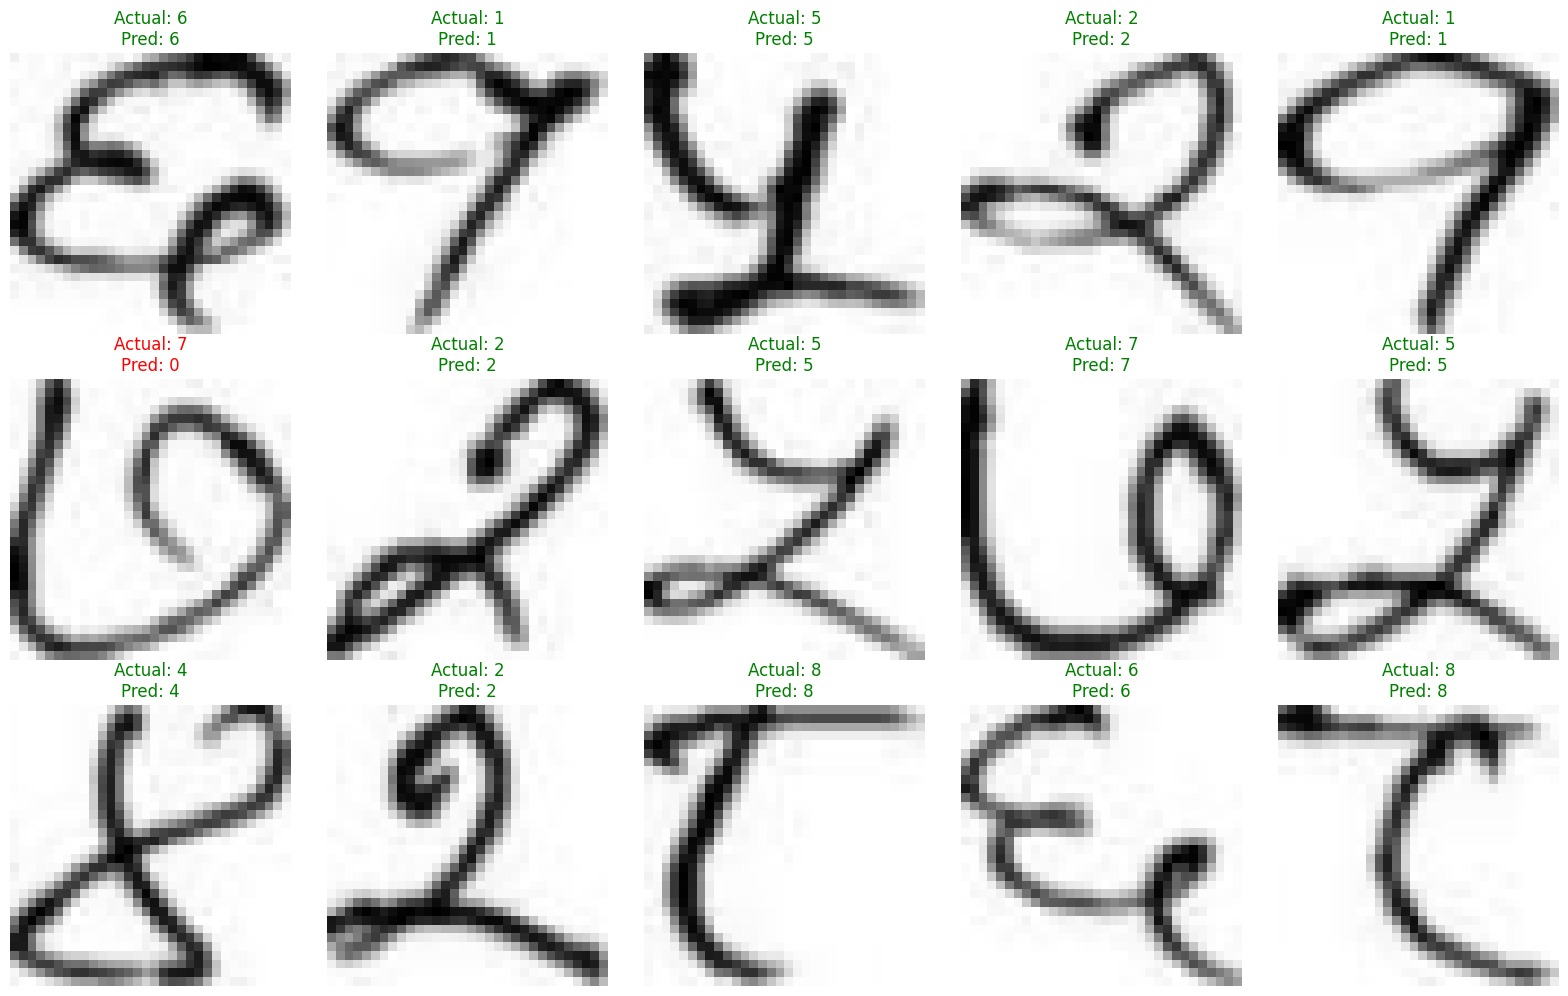


📋 Full Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        36
           1       1.00      1.00      1.00        43
           2       0.95      0.95      0.95        44
           3       0.98      0.98      0.98        47
           4       1.00      0.93      0.97        46
           5       0.96      0.96      0.96        47
           6       0.95      1.00      0.98        42
           7       0.96      0.96      0.96        45
           8       1.00      1.00      1.00        39
           9       1.00      0.98      0.99        43

    accuracy                           0.97       432
   macro avg       0.97      0.98      0.98       432
weighted avg       0.97      0.97      0.97       432


Confusion Matrix:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 43  0  0  0  0  0  0  0  0]
 [ 0  0 42  0  0  2  0  0  0  0]
 [ 0  0  1 46  0  0  0  0  0  0]
 [ 1  0  0  0 43  0  0  2  0  0]
 [ 0  0  1  0  0 45  1  0 

In [1]:
from google.colab import drive
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# ========================= SETUP =========================
drive.mount('/content/drive', force_remount=True)

if not os.path.exists('data'):
    os.system('unzip -q /content/drive/MyDrive/archive.zip -d data/')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_dataset = ImageFolder(root='data/nhcd/nhcd/numerals/', transform=transform)
class_names = full_dataset.classes  # ['0', '1', '2', ..., '9']

print('Total Images:', len(full_dataset))
print('Classes:', class_names)

# Split dataset
train_size = int(0.85 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f'Train: {train_size} | Test: {test_size}')

# ========================= MODEL =========================
class DevanagariCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2   = nn.Conv2d(32, 64, 3, padding=1)
        self.pool    = nn.MaxPool2d(2, 2)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.25)
        self.fc1     = nn.Linear(64 * 8 * 8, 128)
        self.fc2     = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = DevanagariCNN().to(device)
print('Model Ready!')

# ========================= TRAINING =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
best_acc = 0.0

for epoch in range(15):
    # Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    avg_loss = running_loss / len(train_loader)

    # Testing + Collecting Predictions
    model.eval()
    all_preds = []
    all_labels = []
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * correct / total

    print(f'Epoch {epoch+1:2d}/15 | Loss: {avg_loss:.4f} | '
          f'Train: {train_acc:.2f}% | Test: {test_acc:.2f}%')

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"   >>> Best model saved! ({best_acc:.2f}%)")

# ========================= FINAL RESULTS =========================
print("\n" + "="*60)
print("TRAINING FINISHED!")
print(f"Best Test Accuracy: {best_acc:.2f}%")
print("="*60)

# Copy to Drive
import shutil
shutil.copy('best_model.pth', '/content/drive/MyDrive/best_model.pth')
print("Model saved to Google Drive")

# ===================== ACTUAL vs PREDICTED =====================
print("\n📊 Showing 15 Examples (Actual vs Predicted):")

model.eval()
images_batch, labels_batch = next(iter(test_loader))  # Get one batch
images_batch = images_batch.to(device)

with torch.no_grad():
    outputs = model(images_batch)
    _, preds_batch = torch.max(outputs, 1)

# Plot Images with Labels
plt.figure(figsize=(16, 10))
for i in range(15):  # Show 15 images
    plt.subplot(3, 5, i+1)

    img = images_batch[i].cpu().squeeze().numpy()   # Grayscale
    plt.imshow(img, cmap='gray')

    actual = class_names[labels_batch[i].item()]
    predicted = class_names[preds_batch[i].item()]

    color = 'green' if actual == predicted else 'red'
    plt.title(f'Actual: {actual}\nPred: {predicted}', color=color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

# ===================== DETAILED REPORT =====================
print("\n📋 Full Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))